# Part 3: Evaluation & Visualisation

#### Welcome to Part 3!

In Part 2 we trained a linear keyword spotter with **trainable nnAudio2 basis functions**. Here we load those weights, run evaluation on the held-out test set, and visualise what the model actually learned — the adapted Mel filterbank and STFT kernels.

You can use the pre-trained checkpoint supplied in `trained_weight_for_tutorial3/`, or point to your own `lightning_logs/` checkpoint from Part 2.

[Step 1: Imports](#Step-1:-Imports)\
[Step 2: Configuration & device](#Step-2:-Configuration-&-device)\
[Step 3: Test DataLoader](#Step-3:-Test-DataLoader)\
[Step 4: Model definition](#Step-4:-Model-definition)\
[Step 5: Load pre-trained weights](#Step-5:-Load-pre-trained-weights)\
[Step 6: Evaluate](#Step-6:-Evaluate)\
[Step 7: Visualise learned basis functions](#Step-7:-Visualise-learned-basis-functions)

## Step 1: Imports

In [1]:
import os
import re
import itertools
import numpy as np
import matplotlib.pyplot as plt
3
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

from pytorch_lightning import Trainer, LightningModule
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

from nnAudio2.features.mel import MelSpectrogram

/var/folders/xm/qzb5tds96wd1w9ss080zx9q40000gn/T/ipykernel_6247/2724464719.py:17: CitationReminderWarning: ============================================================
nnAudio Citation Reminder

If you like nnAudio, please cite:

K. W. Cheuk, H. Anderson, K. Agres and D. Herremans,
"nnAudio: An on-the-Fly GPU Audio to Spectrogram Conversion
Toolbox Using 1D Convolutional Neural Networks,"
IEEE Access, vol. 8, pp. 161981-162003, 2020,
doi: 10.1109/ACCESS.2020.3019084.

  from nnAudio2.features.mel import MelSpectrogram


## Step 2: Configuration & device

Device is detected automatically — CUDA → MPS (Apple Silicon) → CPU.

In [2]:
if torch.cuda.is_available():
    device, accelerator = 'cuda', 'gpu'
elif torch.backends.mps.is_available():
    device, accelerator = 'mps', 'mps'
else:
    device, accelerator = 'cpu', 'cpu'

print(f"Using device: {device}")

batch_size  = 100
n_mels      = 40
input_dim   = n_mels * 101
output_dim  = 12

data_root       = './'
download_option = True   # set False once downloaded

Using device: mps


## Step 3: Test DataLoader

We only need the test split here — no rebalancing sampler required.

In [3]:
CLASSES       = ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', 'silence', 'unknown']
KEYWORDS      = CLASSES[:10]
LABEL_MAP     = {word: i for i, word in enumerate(KEYWORDS)}
SILENCE_LABEL = 10
UNKNOWN_LABEL = 11
TARGET_LEN    = 16000

class SPEECHCOMMANDS_12C(Dataset):
    """torchaudio SPEECHCOMMANDS mapped to 12 integer classes."""
    def __init__(self, root, url='speech_commands_v0.02',
                 folder_in_archive='SpeechCommands', download=False, subset=None):
        self.base = torchaudio.datasets.SPEECHCOMMANDS(
            root=root, url=url, folder_in_archive=folder_in_archive,
            download=download, subset=subset,
        )
        self.silence = []
        noise_dir = os.path.join(root, folder_in_archive, '_background_noise_')
        if os.path.exists(noise_dir):
            for fname in sorted(os.listdir(noise_dir)):
                if fname.endswith('.wav'):
                    wav, _ = torchaudio.load(os.path.join(noise_dir, fname))
                    for start in range(0, wav.shape[1] - TARGET_LEN, TARGET_LEN):
                        self.silence.append(wav[:, start:start + TARGET_LEN])

    @staticmethod
    def _fix_length(wav):
        n = wav.shape[1]
        if n < TARGET_LEN:
            return torch.nn.functional.pad(wav, (0, TARGET_LEN - n))
        return wav[:, :TARGET_LEN]

    def __len__(self):
        return len(self.base) + len(self.silence)

    def __getitem__(self, idx):
        if idx < len(self.base):
            waveform, sr, label, speaker_id, utt_num = self.base[idx]
            return self._fix_length(waveform), sr, LABEL_MAP.get(label, UNKNOWN_LABEL), speaker_id, utt_num
        return self.silence[idx - len(self.base)], 16000, SILENCE_LABEL, '', 0

def collate_fn(batch):
    waveforms = pad_sequence([b[0].squeeze(0) for b in batch], batch_first=True)
    return {'waveforms': waveforms, 'labels': torch.tensor([b[2] for b in batch])}

testset    = SPEECHCOMMANDS_12C(root=data_root, url='speech_commands_v0.02',
                                folder_in_archive='SpeechCommands',
                                download=download_option, subset='testing')
# num_workers=0 keeps loading in the main process, avoiding pickling errors
# for classes defined in the notebook (__main__)
testloader = DataLoader(testset, batch_size=batch_size, collate_fn=collate_fn, num_workers=0)
print(f"Test samples: {len(testset):,}")

Test samples: 11,005


## Step 4: Model definition

The architecture here must match what was trained in Part 2. We also define two small helper functions for the per-class bar charts and the confusion matrix.

In [4]:
def plot_confusion(labels, preds, title='Confusion matrix'):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
    ax.imshow(cm, cmap='Oranges')
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=6)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES, fontsize=6)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title, fontsize=8)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, str(cm[i, j]) if cm[i, j] else '.', ha='center', va='center', fontsize=5)
    fig.tight_layout()
    return fig

def plot_bars(per_class_values, metric_name, figsize=(5, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(CLASSES, per_class_values)
    ax.set_xlim(0, 1); ax.set_title(metric_name)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    fig.tight_layout()
    fig.savefig(f'{metric_name}.png', bbox_inches='tight')
    return fig


class TrainableKeywordSpotter(LightningModule):
    """Linear keyword spotter — architecture identical to Part 2."""

    def __init__(self, trainable_mel=True, trainable_STFT=True):
        super().__init__()
        self.mel = MelSpectrogram(
            sr=16000, n_fft=480, hop_length=160, n_mels=n_mels,
            fmin=0.0, norm=1,
            trainable_mel=trainable_mel, trainable_STFT=trainable_STFT,
            verbose=False,
        )
        self.classifier    = nn.Linear(n_mels * 101, output_dim)
        self.criterion     = nn.CrossEntropyLoss()
        self._test_outputs = []

    def forward(self, x):
        spec   = torch.log(self.mel(x) + 1e-10)
        logits = self.classifier(spec.flatten(1))
        return logits, spec

    def optimizer_step(self, epoch, batch_idx, optimizer, optimizer_closure=None):
        optimizer.step(closure=optimizer_closure)
        with torch.no_grad():
            torch.clamp_(self.mel.mel_basis, 0, 1)

    def test_step(self, batch, batch_idx):
        logits, _ = self(batch['waveforms'])
        loss = self.criterion(logits, batch['labels'])
        self.log('test_loss', loss, prog_bar=True)
        self._test_outputs.append({
            'logits': logits.detach().cpu(),
            'labels': batch['labels'].detach().cpu(),
        })

    def on_test_epoch_end(self):
        logits = torch.cat([o['logits'] for o in self._test_outputs])
        labels = torch.cat([o['labels'] for o in self._test_outputs])
        self._test_outputs.clear()

        preds = logits.argmax(-1)
        self.log('test_acc', (preds == labels).float().mean())

        for avg in ['micro', 'macro', 'weighted']:
            _, _, f1, _ = precision_recall_fscore_support(labels, preds, average=avg, zero_division=0)
            self.log(f'test_{avg}_f1', float(f1))

        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average=None, zero_division=0)
        plot_bars(p, 'precision'); plot_bars(r, 'recall'); plot_bars(f1, 'f1')
        plot_confusion(labels, preds)
        plt.show()

    def configure_optimizers(self):
        mel_params        = [p for n, p in self.named_parameters() if 'mel.' in n]
        classifier_params = [p for n, p in self.named_parameters() if 'mel.' not in n]
        return optim.Adam([
            {'params': classifier_params, 'lr': 1e-3},
            {'params': mel_params,        'lr': 1e-4},
        ])

## Step 5: Load pre-trained weights

The provided checkpoint (`trained_weight_for_tutorial3/`) was saved with the original attribute names (`mel_layer.`, `linearlayer.`). We remap those keys to match the updated model (`mel.`, `classifier.`) before calling `load_state_dict`.

If you are using your own checkpoint from Part 2 (trained with the updated code), the keys already match and the remapping is a no-op.

> **Match your config:** the checkpoint in `trained_weight_for_tutorial3` was trained with **config D** (`trainable_mel=True, trainable_STFT=True`, `n_mels=40`). Adjust the constructor below if you trained with a different config.

In [5]:
ckpt_path = './trained_weight_for_tutorial3/Linearmodel_nnAudio-speechcommand-mel=trainable-STFT=trainable/version_1/checkpoints/last.ckpt'

model = TrainableKeywordSpotter(trainable_mel=True, trainable_STFT=True)

raw = torch.load(ckpt_path, map_location='cpu')
state_dict = {
    k.replace('mel_layer.', 'mel.').replace('linearlayer.', 'classifier.'): v
    for k, v in raw['state_dict'].items()
}
model.load_state_dict(state_dict)
print("Weights loaded.  Reported test accuracy from original training: ~45.1 %")

Weights loaded.  Reported test accuracy from original training: ~45.1 %


## Step 6: Evaluate

Running `trainer.test()` calls `test_step` on every batch, then `on_test_epoch_end` which logs accuracy, micro/macro/weighted F1, and renders the per-class bar charts and confusion matrix.

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/dorien_herremans/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/dorien_herremans/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: 

Testing DataLoader 0:   0%|          | 0/111 [00:00<?, ?it/s]

/Users/dorien_herremans/Library/Python/3.9/lib/python/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Testing DataLoader 0: 100%|██████████| 111/111 [00:06<00:00, 18.49it/s]

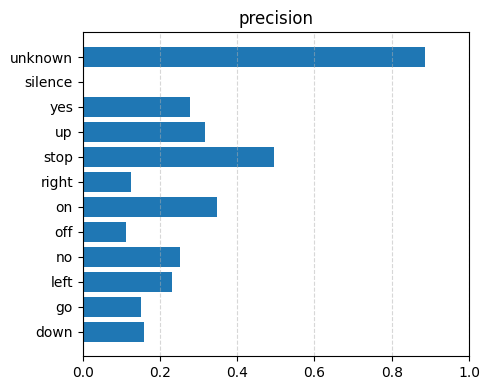

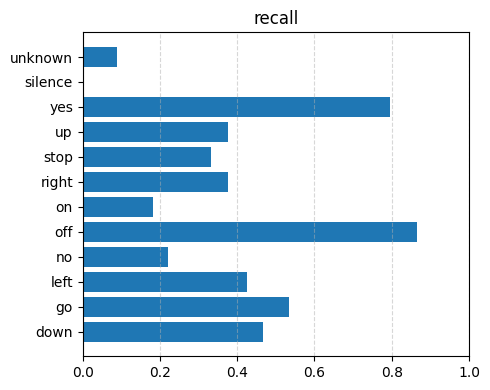

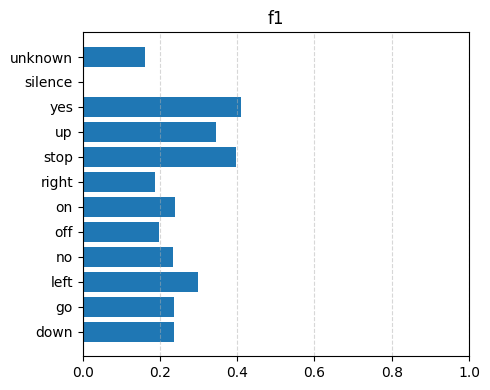

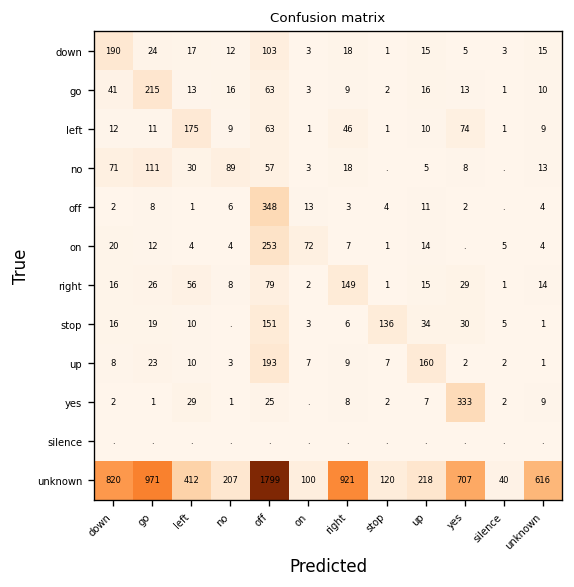

Testing DataLoader 0: 100%|██████████| 111/111 [00:06<00:00, 17.00it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.2256247103214264     │
│         test_loss         │     22.00739097595215     │
│       test_macro_f1       │    0.24518145620822906    │
│       test_micro_f1       │    0.2256247103214264     │
│     test_weighted_f1      │    0.20517432689666748    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 22.00739097595215,
  'test_acc': 0.2256247103214264,
  'test_micro_f1': 0.2256247103214264,
  'test_macro_f1': 0.24518145620822906,
  'test_weighted_f1': 0.20517432689666748}]

In [6]:
trainer = Trainer(accelerator=accelerator, devices=1, num_sanity_val_steps=0)
trainer.test(model, testloader)

## Step 7: Visualise learned basis functions

Because the filterbank weights are `nn.Parameter`s, they are stored in the checkpoint just like any other weight. We can load the raw checkpoint and inspect them directly.

The `state_dict` contains:

```
state_dict
├── mel.mel_basis          # [n_mels, n_fft//2+1]  — learned Mel filterbank
├── mel.stft.wsin          # [n_fft//2+1, 1, n_fft] — learned STFT sine kernels
├── mel.stft.wcos          # [n_fft//2+1, 1, n_fft] — learned STFT cosine kernels
├── mel.stft.window_mask
├── classifier.weight
└── classifier.bias
```

> **Old checkpoints** (saved before the nnAudio2 update) use `mel_layer.` instead of `mel.`. The cell below detects this automatically.

In [7]:
weight     = torch.load(ckpt_path, map_location='cpu')
state_dict = weight['state_dict']

# Auto-detect key prefix for old vs new checkpoints
mel_prefix = 'mel.' if any(k.startswith('mel.') for k in state_dict) else 'mel_layer.'
print(f"Key prefix detected: '{mel_prefix}'")

Key prefix detected: 'mel_layer.'


In [8]:
print("state_dict keys:")
for k in state_dict:
    print(f"  {k:50s}  {tuple(state_dict[k].shape)}")

state_dict keys:
  mel_layer.mel_basis                                 (40, 241)
  mel_layer.stft.wsin                                 (241, 1, 480)
  mel_layer.stft.wcos                                 (241, 1, 480)
  mel_layer.stft.window_mask                          (1, 480, 1)
  linearlayer.weight                                  (12, 4040)
  linearlayer.bias                                    (12,)


### Visualising the Mel bins

`mel_basis` has shape `[n_mels, n_fft//2+1]` — one row per Mel filter. With `trainable_mel=True`, these rows are no longer fixed triangular filters; they have been shaped by the training data.

In [10]:
mel_bins = state_dict[f'{mel_prefix}mel_basis']
print(f"mel_basis shape: {tuple(mel_bins.shape)}  →  [{n_mels} Mel bins × {mel_bins.shape[1]} frequency bins]")

mel_basis shape: (40, 241)  →  [40 Mel bins × 241 frequency bins]


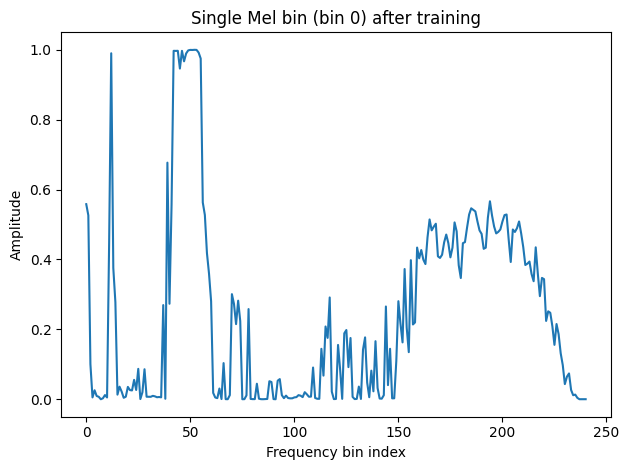

In [11]:
plt.plot(mel_bins[0].cpu().detach().numpy())
plt.title('Single Mel bin (bin 0) after training')
plt.xlabel('Frequency bin index')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

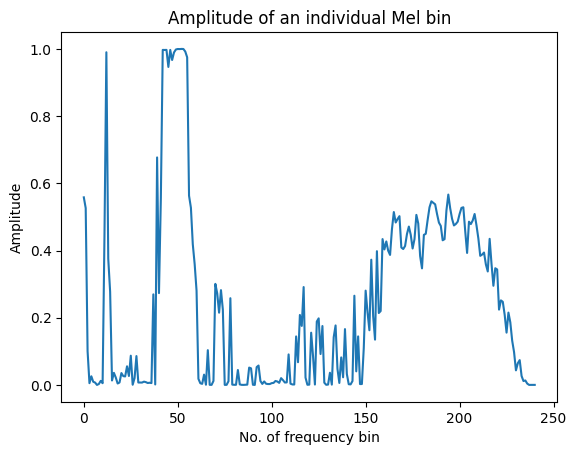

In [12]:
plt.plot(mel_bins[0].cpu().detach().numpy())
plt.title('Amplitude of an individual Mel bin')
plt.xlabel('No. of frequency bin')
plt.ylabel('Amplitude')
plt.show()


**40 Mel bases can be shown in the following:**

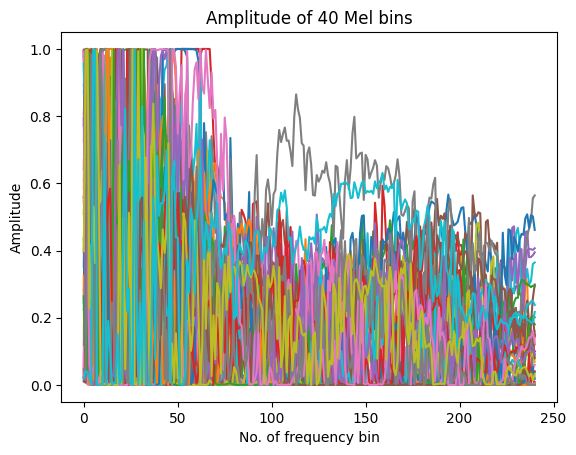

In [13]:
for i in mel_bins:
    plt.plot(i.cpu().detach().numpy()) 
    
plt.title('Amplitude of 40 Mel bins')
plt.xlabel('No. of frequency bin')
plt.ylabel('Amplitude')
plt.show()

### Visualising the STFT kernels

`wsin` and `wcos` each have shape `[n_fft//2+1, 1, n_fft]`. With `trainable_STFT=True`, these sinusoidal kernels are free to deviate from the standard DFT basis during training.

In [14]:
wsin = state_dict[f'{mel_prefix}stft.wsin']
wcos = state_dict[f'{mel_prefix}stft.wcos']
print(f"wsin shape: {tuple(wsin.shape)}")

wsin shape: (241, 1, 480)


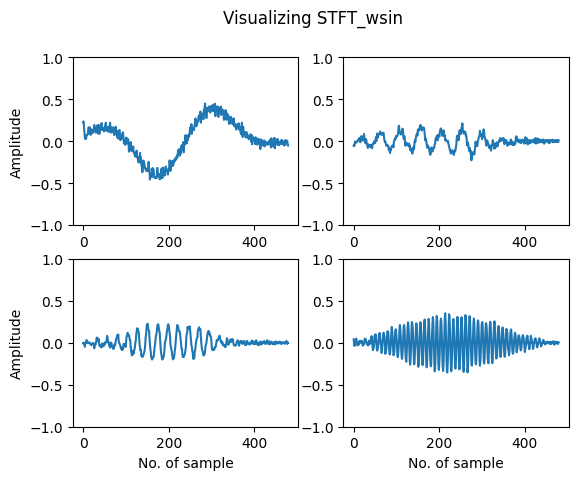

In [15]:
# Visualizing STFT_wsin
fig, axes = plt.subplots(2,2)
for ax, kernel_num in zip(axes.flatten(), [2,10,20,50]):
    ax.plot(wsin[kernel_num,0].cpu())
    ax.set_ylim(-1,1)
    fig.suptitle('Visualizing STFT_wsin')
    
plt.setp(axes[-1, :], xlabel='No. of sample')
plt.setp(axes[:, 0], ylabel='Amplitude')
plt.show()

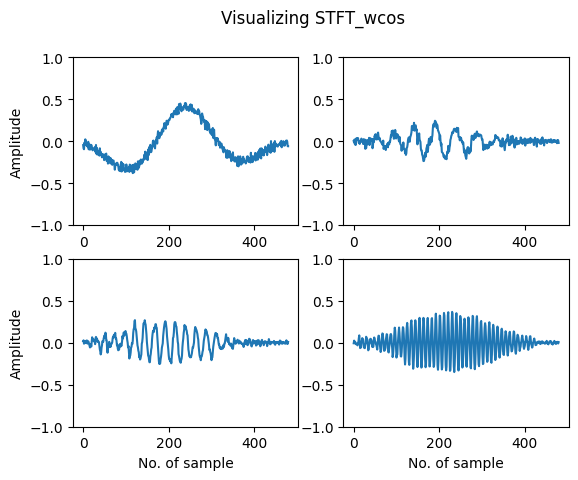

In [16]:
# Visualizing STFT_wcos
fig, axes = plt.subplots(2,2)
for ax, kernel_num in zip(axes.flatten(), [2,10,20,50]):
    ax.plot(wcos[kernel_num,0].cpu())
    ax.set_ylim(-1,1)
    fig.suptitle('Visualizing STFT_wcos')
    
plt.setp(axes[-1, :], xlabel='No. of sample')
plt.setp(axes[:, 0], ylabel='Amplitude')   
plt.show()

## Conclusion

We evaluated the trainable-basis model on the held-out test set and visualised what it learned. The adapted Mel bins and STFT kernels show how the front-end shifts away from the standard DFT basis to better represent keyword-relevant spectral patterns.

In **Part 4** we replace the linear classifier with a deeper BC-ResNet model to push accuracy further.